1.Business goal:
Analyze e-commerce data to understand revenue drivers and customer behavior.
2. Key questions :
- Are there seasonal trends?
- What drives revenue?
- What categories perform best?
- Which customers spend more?
- Do discounts increase sales?




                                       Dataset description:
- cid (Customer ID): A unique identifier for each customer.
- tid (Transaction ID): A unique identifier for each transaction.
- gender: The gender of the customer, categorized as Male or Female.
- age_group: Age group of the customer, divided into several ranges.
- purchase-date: The timestamp of when the transaction took place.
- product_category: The category of the product purchased, such as Electronics, Apparel, etc.
- discount_availed: Indicates whether the customer availed any discount (Yes/No).
- discount_name: Name of the discount applied (e.g., FESTIVE50).
- discount_amount_(inr): The amount of discount availed by the customer.
- gross_amount: The total amount before applying any discount.
- net_amount: The final amount after applying the discount.
- purchase_method: The payment method used (e.g., Credit Card, Debit Card, etc.).
- location: The city where the purchase took place.

First importing the libraries ,downloading data :

In [154]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 

In [155]:
data = pd.read_csv(r'C:\Users\marin\Downloads\eccomerce_csv\ecommerce1_df.csv')

- Now we will get aquanted with dataset and provide cleaning/preproccessing:

In [156]:
data.shape
print(f'dataset contains  {data.shape[0]} rows and {data.shape[1]} columns.')

dataset contains  55000 rows and 13 columns.


In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


In [158]:
data.head(5)

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.30,661.00,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,"4,638.99","4,463.80",Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,"1,986.37","1,774.83",Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,NaN,0.00,"5,695.61","5,695.61",Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,"2,292.65","1,852.73",Credit Card,Delhi


- Lets start with transformation  of  column names :


In [159]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(' ','_'))

- Also will convert 'tid','cid' columns to object type:

In [160]:
id_cols = ['cid','tid']
for col in id_cols:
    data[col] = data[col].astype(str)

- Checking the presence of missing values in all columns:

In [161]:
missing_data = data.isnull().sum()
missing_percent = (missing_data/len(data))*100
missing_percent

cid                      0.00
tid                      0.00
gender                   0.00
age_group                0.00
purchase_date            0.00
product_category         0.00
discount_availed         0.00
discount_name           50.15
discount_amount_(inr)    0.00
gross_amount             0.00
net_amount               0.00
purchase_method          0.00
location                 0.00
dtype: float64

- We can see that the column 'discount_name' has 50% of missing values.The best decision here I see is to create category 'unknown' for those values.

In [162]:
data['discount_name'] = data['discount_name'].fillna('unknown')

- The next step is to check the dataset for duplicates.

In [163]:
data.duplicated().sum()

np.int64(0)

- Dataset doesn't have any duplicates.Lets check general statistics :

In [164]:
data.describe()

,discount_amount_(inr),gross_amount,net_amount
count,"55,000.00","55,000.00","55,000.00"
mean,136.99,"3,012.94","2,875.95"
std,165.38,"1,718.43","1,726.13"
min,0.00,136.45,-351.12
25%,0.00,"1,562.11","1,429.55"
50%,0.00,"2,954.27","2,814.91"
75%,274.12,"4,342.22","4,211.41"
max,500.00,"8,394.83","8,394.83"


- We investigated that there is negative value of net price.Lets dive deeper and see how much rows like this we get:

In [165]:
(data['net_amount'] < 0).sum()


np.int64(613)

- We have 613 negative values of the final price what indicates logic problem or error in data. Due to the fact  that is less then 2% we will delete this rows .

In [166]:
data = data[data['net_amount'] >= 0]

- Check of outliers:

In [167]:
Q1 = data['net_amount'].quantile(0.25)
Q3 = data['net_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['net_amount'] < lower_bound) |
    (data['net_amount'] > upper_bound)
]

print(outliers.shape[0])

2


In [168]:
outlier_percent = (
    outliers.shape[0] / data.shape[0]
) * 100
outlier_percent

0.003677349366576572

In [169]:
Q1 = data['gross_amount'].quantile(0.25)
Q3 = data['gross_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['gross_amount'] < lower_bound) |
    (data['gross_amount'] > upper_bound)
]

print(outliers.shape[0])

0


- A small number of outliers was detected in the order amount columns. Since these transaction may represent real high-value purchases, they were retained for business analysis.
- Now we will check amount of unique values for categorical columns.

In [170]:
cat_cols = data.select_dtypes(include='object').nunique()
cat_cols

cid                 28921
tid                 54387
gender                  3
age_group               5
purchase_date       54377
product_category        9
discount_availed        2
discount_name           6
purchase_method         8
location               14
dtype: int64

- Will check what values we have for object columns:

In [171]:
for col in data.select_dtypes(include='object').columns:
    print(col)
    print(data[col].unique())

cid
['943146' '180079' '337580' ... '306954' '649543' '649435']
tid
['5876328741' '1018503182' '3814082218' ... '9587323189' '5032564481'
 '9172953722']
gender
['Female' 'Male' 'Other']
age_group
['25-45' '60 and above' '18-25' '45-60' 'under 18']
purchase_date
['30/08/2023 20:27:08' '23/02/2024 09:33:46' '06/03/2022 09:09:50' ...
 '02/08/2024 09:30:44' '05/08/2020 23:57:56' '21/07/2022 09:05:18']
product_category
['Electronics' 'Clothing' 'Sports & Fitness' 'Pet Care' 'Home & Kitchen'
 'Books' 'Beauty and Health' 'Other' 'Toys & Games']
discount_availed
['Yes' 'No']
discount_name
['FESTIVE50' 'SEASONALOFFER21' 'unknown' 'WELCOME5' 'SAVE10' 'NEWYEARS']
purchase_method
['Credit Card' 'Debit Card' 'PhonePe UPI' 'Google Pay UPI' 'Net Banking'
 'Cash on Delivery' 'Paytm UPI' 'International Card']
location
['Ahmedabad' 'Bangalore' 'Delhi' 'Other' 'Chennai' 'Dehradun' 'Pune'
 'Hyderabad' 'Mumbai' 'Jaipur' 'Lucknow' 'Kolkata' 'Srinagar' 'Varanasi']


- To optimize memory and code speed will convert object columns to categorical because we have low-cardinality features:

In [172]:
data[data.select_dtypes(include='object').columns] = \
    data.select_dtypes(include='object').astype('category')

- Converting date to datetime format for the further actions in dataset.

In [173]:
data['purchase_date'] = pd.to_datetime(data['purchase_date'],dayfirst=True)

In [174]:
data = data.sort_values('purchase_date')

- Decomposing the date on components for the further use and create categorical month column:

In [175]:
data['year'] = data['purchase_date'].dt.year
data['month'] = data['purchase_date'].dt.month
data['weekday'] = data['purchase_date'].dt.day_name()
data['day'] = data['purchase_date'].dt.day
data['hour'] = data['purchase_date'].dt.hour

In [176]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
data['month_name'] = pd.Categorical(
    data['purchase_date'].dt.strftime('%b'),
    categories=month_order,
    ordered = True)
        

In [177]:
data.to_csv('clean_ecommerce.scv',index=False)

- Next we will connect to mySQL via SQLalhcemy.

In [178]:
from dotenv import load_dotenv
import os 
from sqlalchemy import create_engine
load_dotenv(dotenv_path="credentials.env")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
)
#connection
engine = create_engine(

    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")
# download
data.to_sql('ecommerce', con=engine, if_exists='replace', index=False)

print("Data is downloaded successfully !")

Data is downloaded successfully !


- We will change the setting to get rid of scientific notation:

In [179]:
pd.options.display.float_format = '{:,.2f}'.format

- First we will check the range of time in dataset:

In [180]:
max_min = """
SELECT MAX(purchase_date), MIN(purchase_date)
FROM ecommerce;
"""
result4 = pd.read_sql(max_min, engine)
result4

,MAX(purchase_date),MIN(purchase_date)
0,2024-09-18 16:00:08,2019-09-19 11:46:07


In [181]:
data_2019 = """
SELECT MONTHNAME(purchase_date) AS month,COUNT(*)AS orders
FROM ecommerce
WHERE year = 2019
GROUP BY 1;
"""
data_2019 = pd.read_sql(data_2019, engine)
data_2019

,month,orders
0,September,349
1,October,966
2,November,848
3,December,903


In [182]:
data_2024 = """
SELECT  MONTHNAME(purchase_date) AS month,COUNT(tid)AS orders
FROM ecommerce
WHERE year = 2024
GROUP BY  MONTHNAME(purchase_date);
"""
data_2024 = pd.read_sql(data_2024, engine)
data_2024

,month,orders
0,January,934
1,February,795
2,March,959
3,April,949
4,May,900
5,June,894
6,July,919
7,August,931
8,September,497


- We have data in interval of 5 years.Data for 2024 and 2019 years is incomplete.We will not use them for yearly metrics comparison.
- Lets check key metrics within the years  :
- Total Revenue :

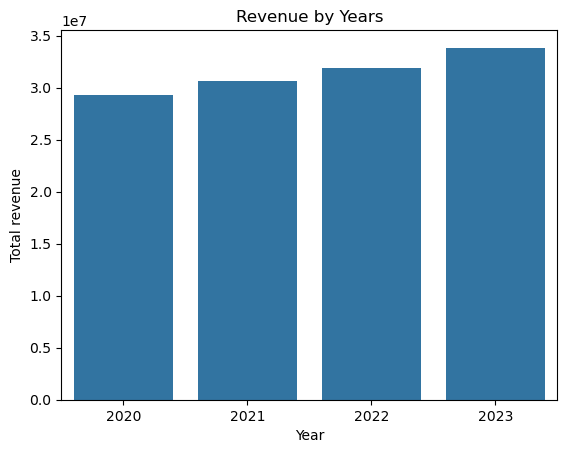

In [183]:
yearly_revenue = """
SELECT YEAR(purchase_date) as year,
SUM(net_amount)AS total_revenue
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1;
"""
yearly_revenue = pd.read_sql(yearly_revenue, engine)

sns.barplot(data=yearly_revenue,
             x='year',
             y='total_revenue',
             )
plt.title('Revenue by Years')
plt.xlabel('Year')
plt.ylabel('Total revenue')
plt.show()


- Business has a growth tendency in revenue what is good.Let's dive deeper and see the drivers of it.

- Amount of transactions:

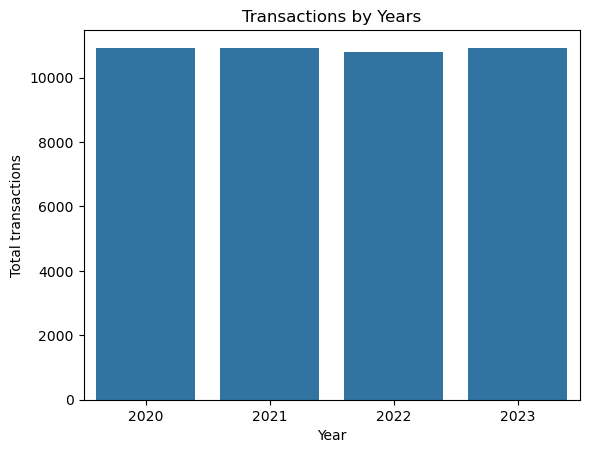

In [184]:
trans = """
SELECT YEAR(purchase_date) as year,
COUNT(tid)AS total_transactions
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1;
"""
trans = pd.read_sql(trans, engine)

sns.barplot(trans,
             x='year',
             y='total_transactions',
             )
plt.title('Transactions by Years')
plt.xlabel('Year')
plt.ylabel('Total transactions')
plt.show()

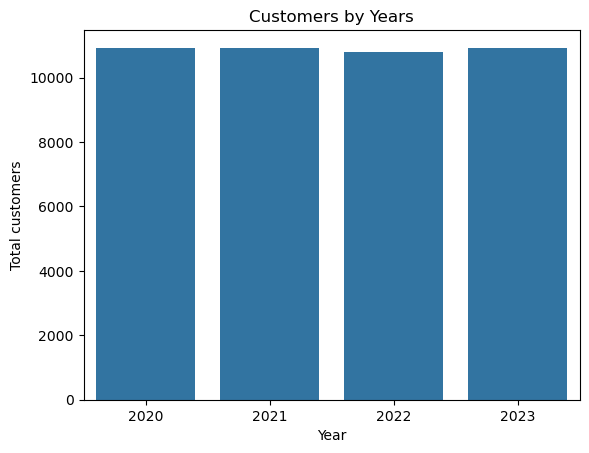

In [185]:
customers = """
SELECT YEAR(purchase_date) as year,
COUNT(cid)AS total_customers
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1;
"""
customers = pd.read_sql(customers, engine)

sns.barplot(customers,
             x='year',
             y='total_customers',
             )
plt.title('Customers by Years')
plt.xlabel('Year')
plt.ylabel('Total customers')
plt.show()

- Average Order Value

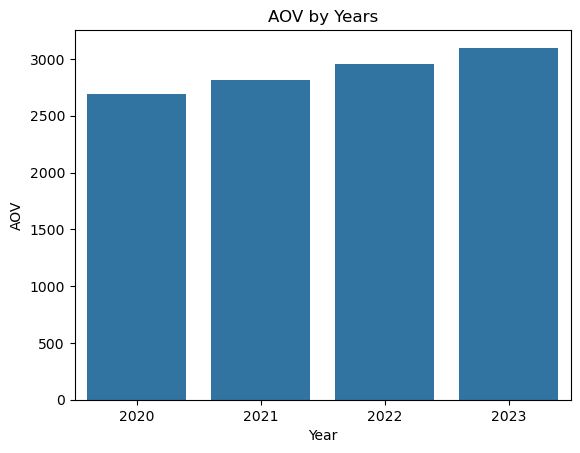

In [186]:
AOV = """
SELECT YEAR(purchase_date) as year,
SUM(net_amount)/COUNT(tid)AS AOV
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1;
"""
AOV = pd.read_sql(AOV, engine)

sns.barplot(AOV,
             x='year',
             y='AOV',
             )
plt.title('AOV by Years')
plt.xlabel('Year')
plt.ylabel('AOV')
plt.show()

- Average Revenue per User

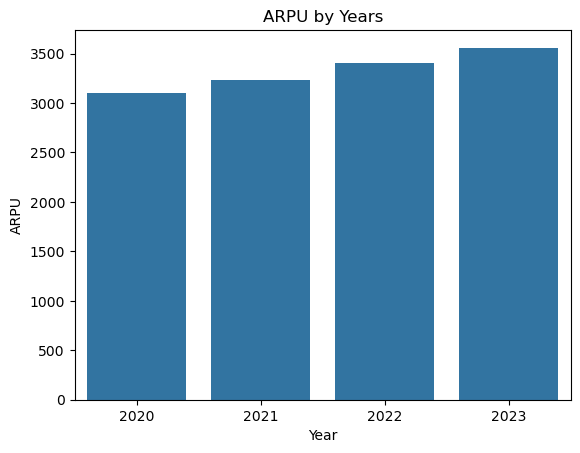

In [187]:
ARPU = """
SELECT YEAR(purchase_date) as year,
ROUND(SUM(net_amount) / COUNT(DISTINCT cid),2) AS ARPU
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1;
"""
ARPU = pd.read_sql(ARPU, engine)

sns.barplot(ARPU,
             x='year',
             y='ARPU',
             )
plt.title('ARPU by Years')
plt.xlabel('Year')
plt.ylabel('ARPU')
plt.show()

- Within the years we have stable amount of purchases with the slight drop in 2022.
- Amount of customers stable during the years.
- Revenue growth was driven by higher customer value what indicates that customers are spending more per order and generating higher revenue per user.
  - But is it:
- Customers became more loyal ?
- What a share of customers who did more then one purchase?
- Premium products gained popularity?
- Pricing strategy improved?
- Discounts may have encouraged larger baskets?
Lets figure it out.

In [188]:
more_then_1_purchase_by_years = """
SELECT year, COUNT(DISTINCT CASE WHEN orders_count > 1 THEN cid END) * 100.0 / COUNT(DISTINCT cid) AS repeat_customer_rate
FROM (SELECT YEAR(purchase_date) as year,cid,COUNT(DISTINCT tid) AS orders_count
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 

GROUP BY 1,2) t 
GROUP BY 1
ORDER BY 1;
"""
more_then_1_purchase_by_years = pd.read_sql(more_then_1_purchase_by_years,engine)
more_then_1_purchase_by_years


,year,repeat_customer_rate
0,2020,13.99
1,2021,13.62
2,2022,13.63
3,2023,13.54


In [189]:
more_then_1_purchase = """
SELECT  COUNT(DISTINCT CASE WHEN orders_count > 1 THEN cid END) * 100.0 / COUNT(DISTINCT cid) AS repeat_customer_rate
FROM (SELECT cid,COUNT(DISTINCT tid) AS orders_count
FROM ecommerce
GROUP BY 1) t ;

"""
more_then_1_purchase = pd.read_sql(more_then_1_purchase,engine)
more_then_1_purchase


,repeat_customer_rate
0,54.84


- Overall, 55% of customers made repeat purchases across the entire dataset. However, only around 14% placed more than one order within the same year, suggesting that repeat purchases are spread over longer periods rather than occurring frequently within a single year.

Now we can dive deeper into analysis and see the seasonal trends during the years:

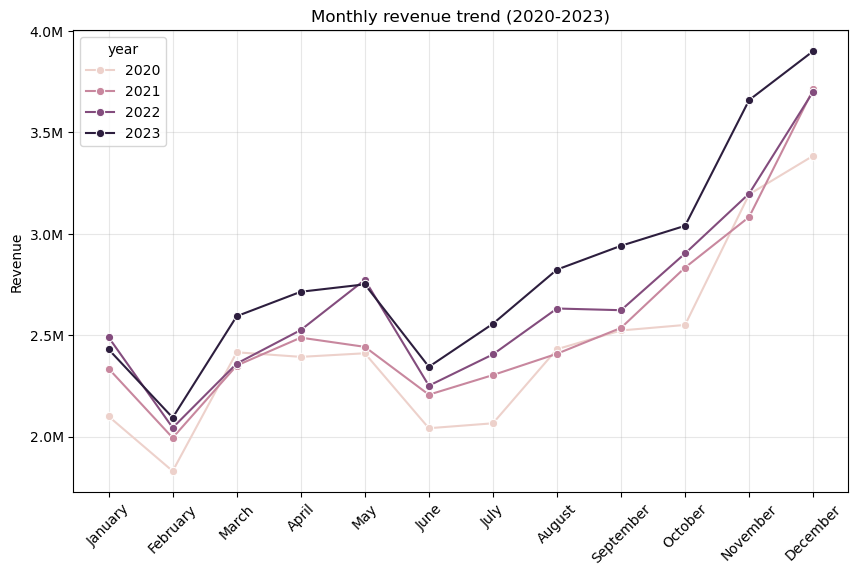

In [190]:
revenue_by_months = """
SELECT YEAR(purchase_date)AS year ,MONTHNAME(purchase_date) AS month,SUM(net_amount)AS total_revenue
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1,2;
"""
revenue_by_months = pd.read_sql(revenue_by_months, engine)

import matplotlib.ticker as ticker


plt.figure(figsize=(10,6))
sns.lineplot(data= revenue_by_months,x='month',y='total_revenue',hue='year',marker='o')
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
plt.xticks(rotation = 45)
plt.title('Monthly revenue trend (2020-2023)')
plt.xlabel('')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.show()

- Revenue consistently dips in February across all years.
- Starting from August-September revenue begin to grow steadily.
- The strongest performance in Q4 especially in November and December 
- 2023 demonstrates largest growth compared to previous years.

Now we will check the amount of transactions by month/year.

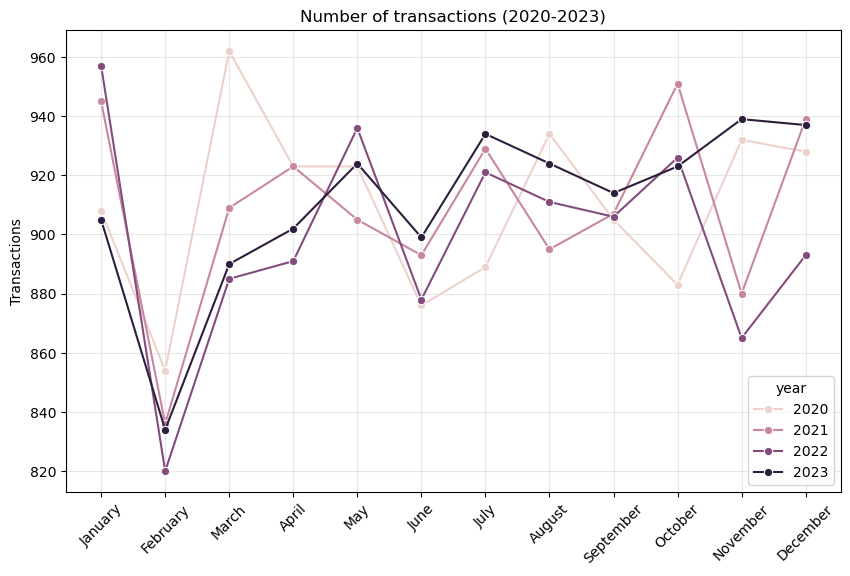

In [191]:
trans_by_month = """
SELECT YEAR(purchase_date)AS year ,MONTHNAME(purchase_date) AS month,COUNT(tid)AS transactions
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1,2;
"""
trans_by_month = pd.read_sql(trans_by_month, engine)

plt.figure(figsize=(10,6))
sns.lineplot(data= trans_by_month,x='month',y='transactions',hue='year',marker='o')
plt.xticks(rotation=45)
plt.title('Number of transactions (2020-2023)')
plt.xlabel('')
plt.ylabel('Transactions')
plt.grid(alpha=0.3)
plt.show()

- February consistently shows the lowest number of transactions across all years.
- Transaction volume tends to recover from March onward.
- Overall transaction levels remain relatively stable between years.

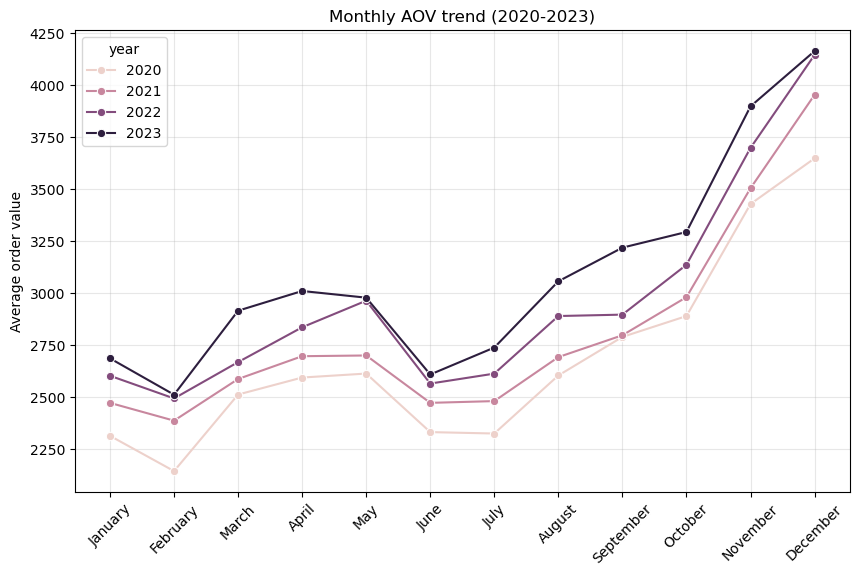

In [192]:
monthly_aov = """
SELECT YEAR(purchase_date)AS year ,MONTHNAME(purchase_date) AS month,SUM(net_amount)/COUNT(tid)AS AOV
FROM ecommerce
WHERE year BETWEEN 2020 AND 2023 
GROUP BY 1,2;
"""
monthly_aov = pd.read_sql(monthly_aov, engine)

plt.figure(figsize=(10,6))
sns.lineplot(data= monthly_aov,x='month',y='AOV',hue='year',marker='o')
plt.xticks(rotation=45)
plt.title('Monthly AOV trend (2020-2023)')
plt.xlabel('')
plt.ylabel('Average order value')
plt.grid(alpha=0.3)
plt.show()

- Average Order Value steadily increased year over year.
- The strongest AOV growth occurred in Q4, especially in November and December.
- Since transaction volume remained relatively stable, revenue growth was likely driven by higher customer spending per order.
- 2023 achieved the highest AOV across nearly all years.

Now lets check the key metrics and find Top categories by volume purchase and revenue :


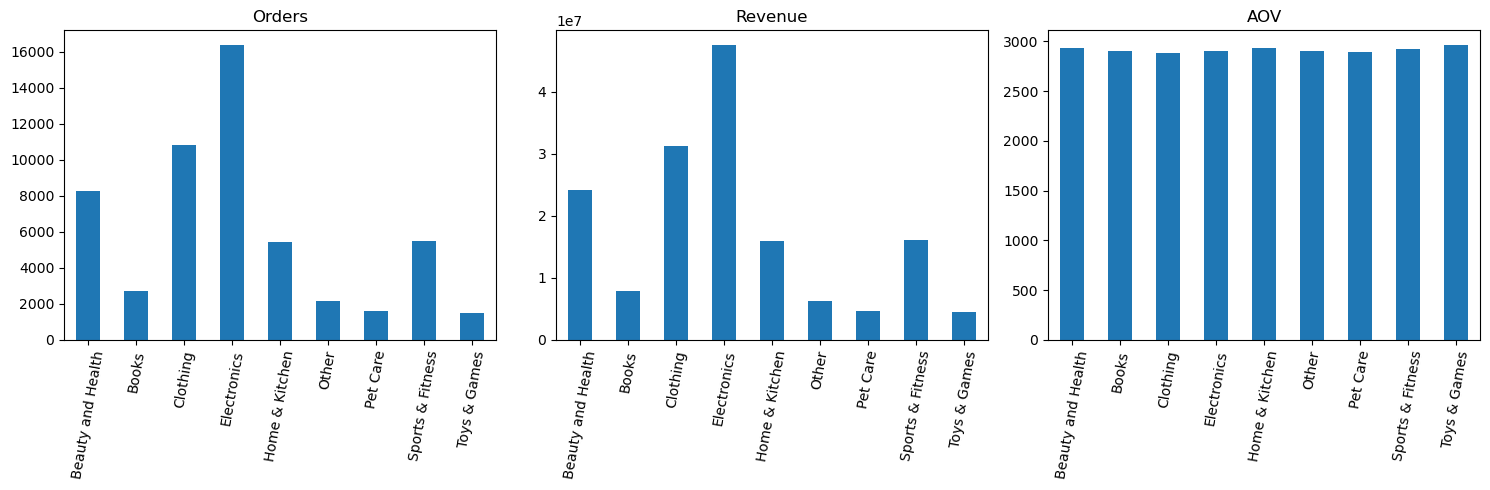

In [193]:
cat_revenue =(data.groupby('product_category',observed=True).agg(revenue = ('net_amount','sum'),
                                                        orders=('tid','nunique')).reset_index())
cat_revenue['AOV'] = cat_revenue['revenue'] / cat_revenue['orders']
cat_revenue.sort_values('revenue', ascending = False)

fig,axes = plt.subplots(1,3,figsize = (15,5))
cat_revenue['orders'].plot.bar(ax=axes[0],title='Orders')
cat_revenue['revenue'].plot.bar(ax=axes[1],title='Revenue')
cat_revenue['AOV'].plot.bar(ax=axes[2],title='AOV')
for ax in axes :
    ax.set_xticklabels(cat_revenue['product_category'],rotation=80)
plt.tight_layout()
plt.show()

- Average Order Value by categories almost same but revenue and purchase volume have significant  difference
- Top categories is Electronics,Clothing and Beauty and Health

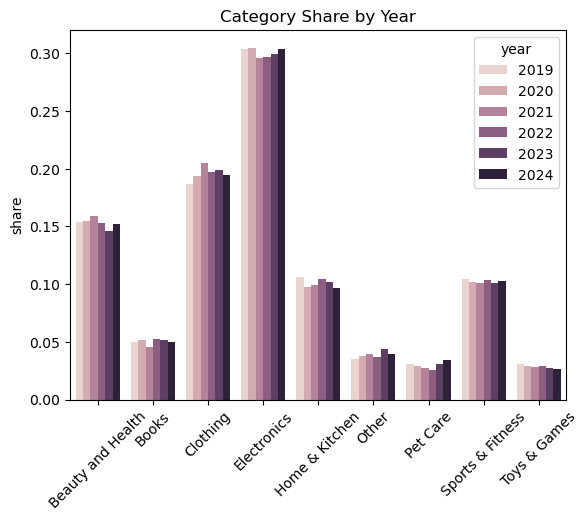

In [194]:
cat_share = (
    data.groupby(['year', 'product_category'],observed=True)
    .agg(revenue=('net_amount', 'sum'))
    .reset_index()
)

cat_share['share'] = (
    cat_share['revenue'] /
    cat_share.groupby('year')['revenue'].transform('sum')
)
cat_share.sort_values('share',ascending = False)

sns.barplot(data=cat_share, x ='product_category', y = 'share',hue = 'year')
plt.xticks(rotation=45)
plt.xlabel('')
plt.title("Category Share by Year")
plt.show()


- Electronics consistently generated the highest share of revenue across all years, contributing around 30% of total sales.
- Overall category distribution remained relatively stable over time, suggesting consistent customer purchasing behavior.
- Small growth trends were observed in Pet Care and Other categories, while Beauty & Health slightly declined in share.
- This indicates that overall revenue growth was likely driven by increased order volume or higher AOV rather than major shifts in product category preferences.

Lets compare revenue by gender and categories. For this we will use pivot_table from pandas .

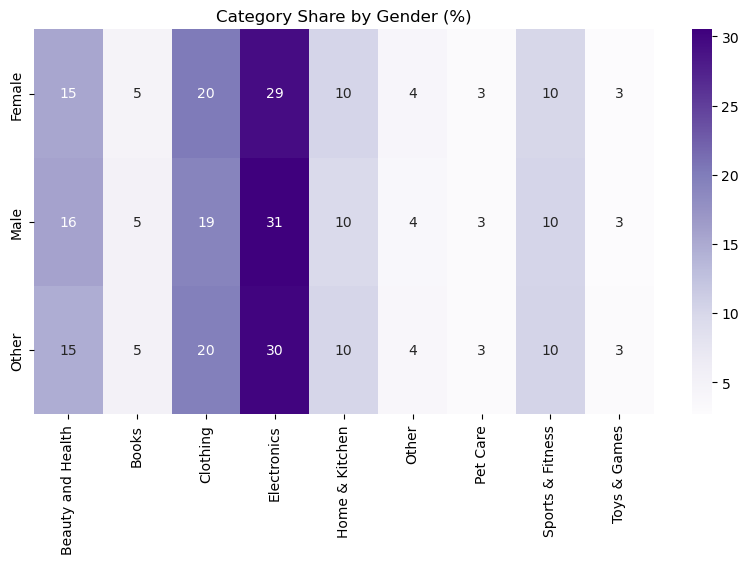

In [195]:
pivot = pd.pivot_table (data=data, values = 'net_amount',index = 'gender', columns ='product_category',aggfunc = 'sum',observed=True)
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot_percent,
    annot=True,
    fmt='.0f',
    cmap='Purples')
plt.xlabel('')
plt.ylabel('')
plt.title('Category Share by Gender (%)')
plt.show()

- Electronics accounts for the largest share of spending across all genders.
- Male customers allocate a larger share of spending to electronics.
- Spending distribution across categories is generally similiar between genders.

Now we will check if discount availed customers tend to buy more and ivestigate the impact of discounts on the business:

In [196]:
pivot2 = pd.pivot_table (data=data, values = 'net_amount',index = 'discount_availed', columns ='product_category',aggfunc = 'sum',observed=True)
pivot2

product_category,Beauty and Health,Books,Clothing,Electronics,Home & Kitchen,Other,Pet Care,Sports & Fitness,Toys & Games
discount_availed,,,,,,,,,
No,"12,850,343.82","4,167,437.08","16,224,498.96","25,101,064.24","8,201,259.85","3,246,552.41","2,519,572.49","8,488,333.01","2,325,010.08"
Yes,"11,343,050.93","3,768,036.71","15,010,085.31","22,406,648.56","7,697,941.40","2,965,821.89","2,118,897.01","7,656,011.66","2,154,060.78"


In [197]:
pivot3 = pd.pivot_table (data=data, values = 'tid',index = 'discount_availed', columns ='product_category',aggfunc = 'count',observed=True)
pivot3

product_category,Beauty and Health,Books,Clothing,Electronics,Home & Kitchen,Other,Pet Care,Sports & Fitness,Toys & Games
discount_availed,,,,,,,,,
No,4244,1373,5439,8367,2705,1067,843,2785,762
Yes,4011,1361,5394,7995,2724,1076,762,2729,750


There is no tendency that discounts lead to bigger spending or purchases.Lets dive deeper and analize the impact of it on key metrics:

In [198]:
data['discount_flag'] = data['discount_availed'].map({'Yes': 1, 'No': 0}).astype(int)

In [199]:
data.groupby('month').agg(
    discount_rate=('discount_flag', 'mean'),
    discount_orders=('discount_flag', 'sum'),
    total_orders=('discount_flag', 'count')
)

,discount_rate,discount_orders,total_orders
month,,,
1,0.48,2226,4649
2,0.48,2004,4139
3,0.49,2262,4605
4,0.51,2321,4588
5,0.49,2261,4588
6,0.49,2172,4440
7,0.50,2276,4592
8,0.49,2237,4595
9,0.50,2239,4478


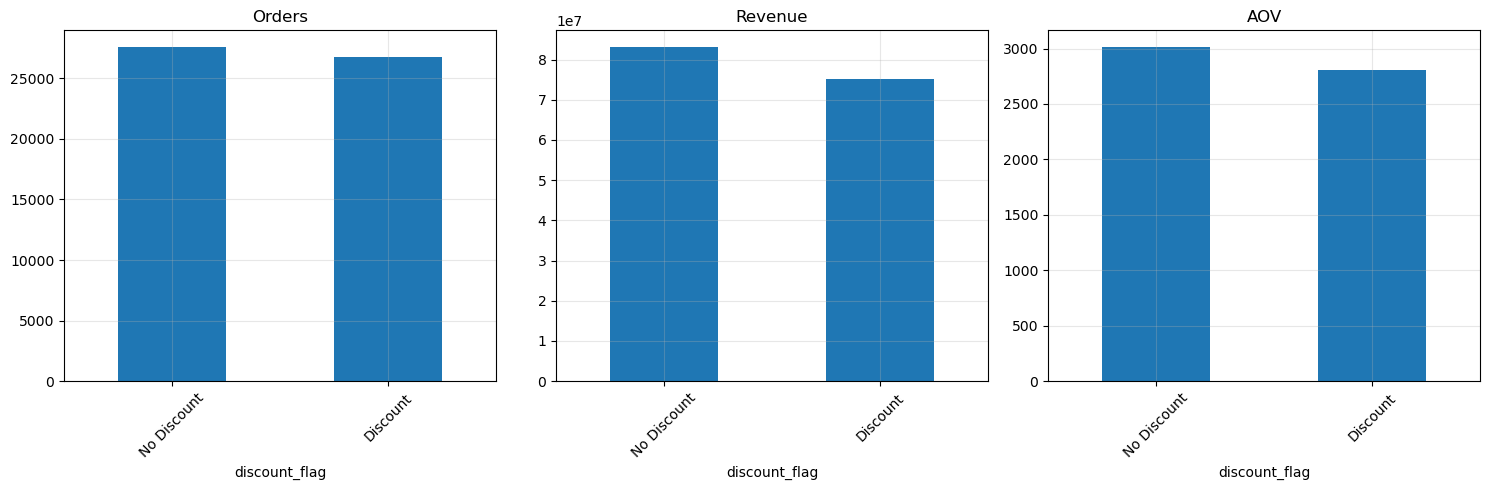

In [200]:
df = data.groupby('discount_flag').agg(
    orders=('tid','count'),
    revenue=('net_amount','sum'),
    AOV=('net_amount','mean'))

fig,axes = plt.subplots(1,3,figsize = (15,5))
df['orders'].plot.bar(ax=axes[0],title='Orders')
df['revenue'].plot.bar(ax=axes[1],title='Revenue')
df['AOV'].plot.bar(ax=axes[2],title='AOV')
for ax in axes :
    ax.set_xticklabels(['No Discount','Discount'],rotation=45)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

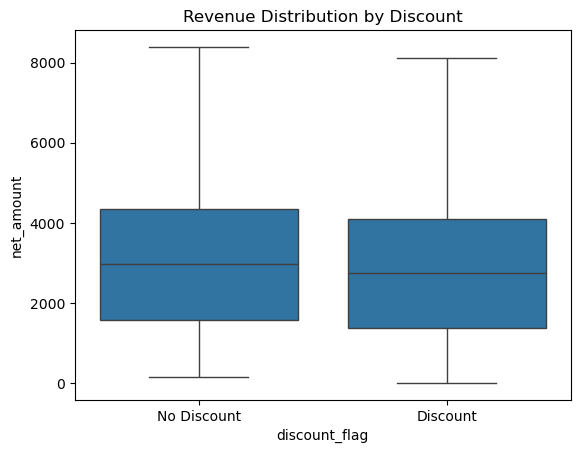

In [201]:
sns.boxplot(x='discount_flag', y= 'net_amount',data=data)
plt.xticks([0,1],['No Discount','Discount'])
plt.title('Revenue Distribution by Discount')
plt.show()

In [202]:
ARPU = data.groupby('discount_flag').agg(
    users=('cid', 'nunique'),
    revenue=('net_amount', 'sum')
).assign(ARPU=lambda x: x['revenue'] / x['users'])

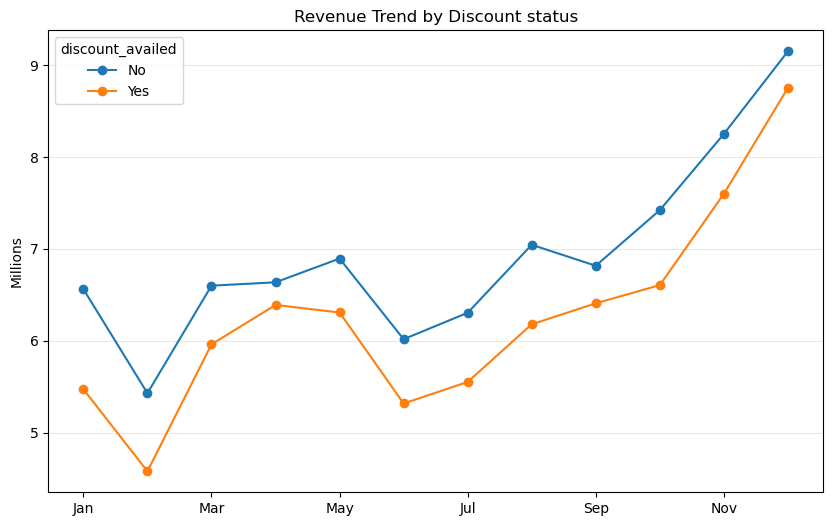

In [234]:
monthly_rev = data.groupby(['month_name','discount_availed'],observed=True)['net_amount'].sum().unstack() / 1000000

monthly_rev.plot(figsize=(10,6),marker='o')
plt.title('Revenue Trend by Discount status')
plt.ticklabel_format(style='plain',axis='y')
plt.grid(axis='y',alpha=0.3)
plt.ylabel("Revenue")
plt.ylabel('Millions')
plt.xlabel('')
plt.show()

- Discount did not significantly increase the number of orders,but reduced both average order value and revenue per user .
- This suggests that discounts are not effective and may be decreasing overall profitability.
Key insights:
- Discounts did not increase demand
- The number of orders nearly identical .
- Discounts are not driven additional purchases.
- AOV decreased with discounts by 7%
- ARPU decreased with discounts  by 8%
- Revenue is lower with discounts  by 10%
- The Customers were already 'ready to buy'
- Discounts are not effective in this case.

Discounts:

- Do NOT increase the number of orders
- Reduce AOV
- Reduce revenue per user

 This suggests that discounts are mainly given to customers who would have purchased anyway.

⸻

  ---Business Implications

Current discount strategy may be:

- Reducing profitability
- Not improving customer acquisition
- Not increasing demand

⸻

--- Recommendations

- Limit blanket discounts
- Avoid giving discounts to all users
- Target discounts strategically
- Run A/B tests
- Compare discount vs no-discount groups
- Analyze customer segments
- Identify where discounts actually work


In [204]:
age_group_stat = data.groupby('age_group',observed=True).agg(
    customers=('cid','nunique'),
    orders=('tid','count'),
    revenue=('net_amount','sum'),
    AOV=('net_amount','mean'))

In [205]:
age_group_arpu = data.groupby('age_group',observed=True).agg(
    users=('cid', 'nunique'),
    revenue=('net_amount', 'sum')
).assign(ARPU=lambda x: x['revenue'] / x['users'])

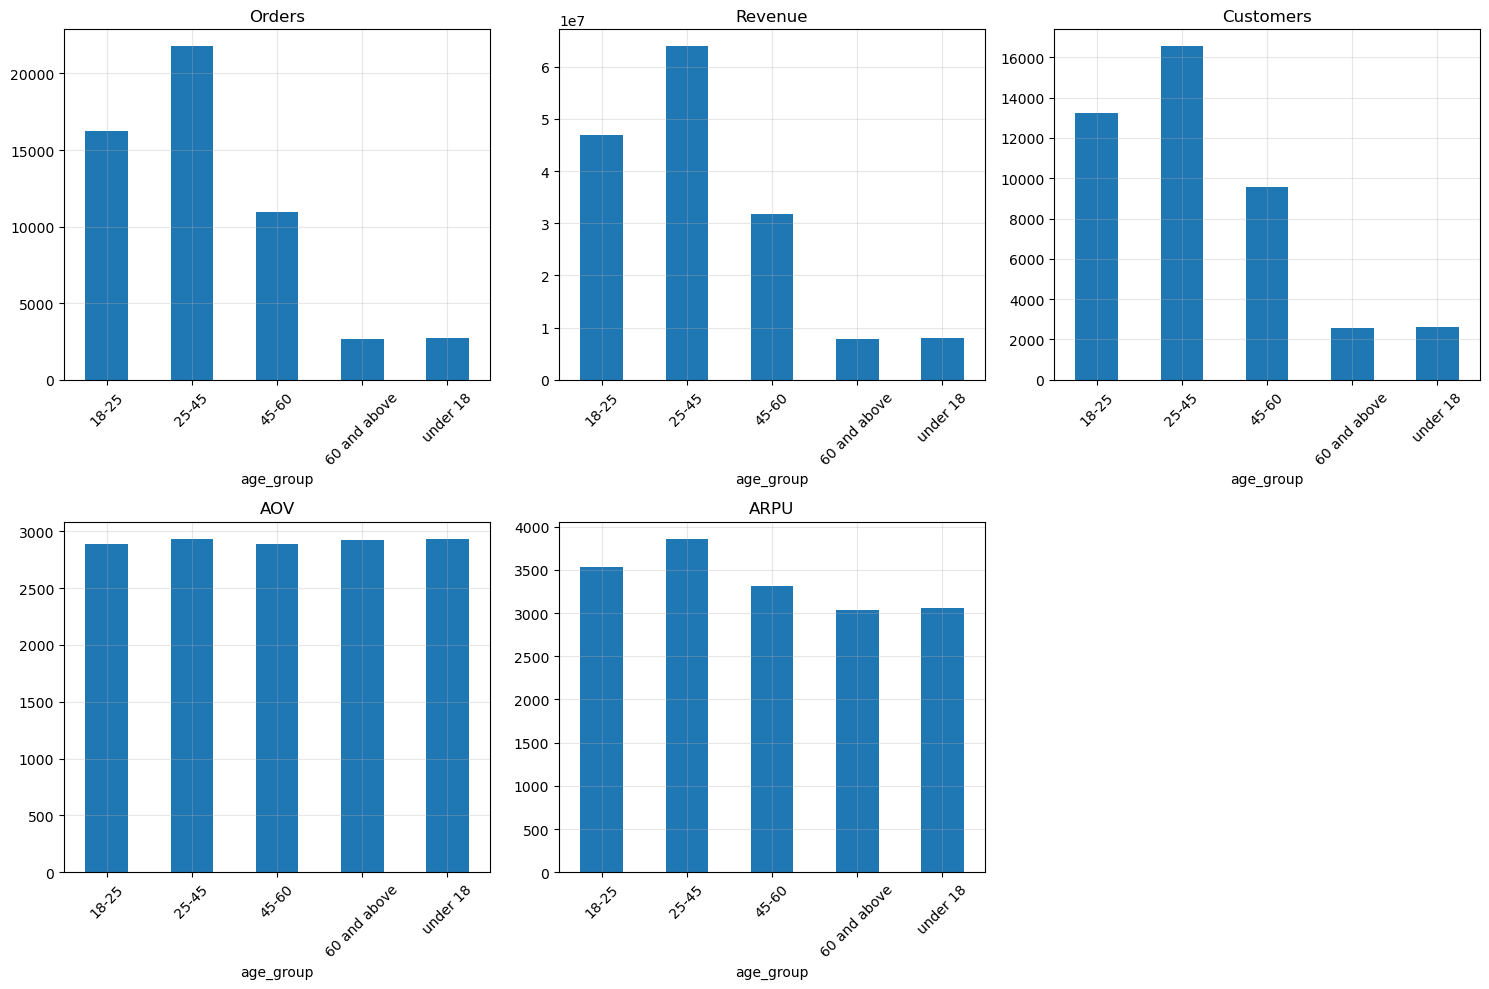

In [206]:
fig,axes = plt.subplots(2,3,figsize = (15,10))

axes = axes.flatten()

age_group_stat['orders'].plot.bar(ax=axes[0],title='Orders')
age_group_stat['revenue'].plot.bar(ax=axes[1],title='Revenue')
age_group_stat['customers'].plot.bar(ax=axes[2],title='Customers')
age_group_stat['AOV'].plot.bar(ax=axes[3],title='AOV')
age_group_arpu['ARPU'].plot.bar(ax=axes[4],title='ARPU')

for ax in axes:
    ax.tick_params(axis='x',rotation=45)
    ax.grid(alpha=0.3)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

- The 25–45 age group generated the highest revenue, orders, and customer count.
-  However, AOV remained relatively stable across all age groups, suggesting that higher revenue was mainly driven by a larger customer base and higher purchase volume rather than higher spending per order.
-  The higher ARPU for this segment indicates that customers aged 25–45 are the most valuable customer group.
  

                                    - Full-History RFM Analysis

In [207]:
snapshot_date = data['purchase_date'].max() + pd.Timedelta(days=1)

In [208]:
rfm = data.groupby('cid', observed = True).agg({
    'purchase_date' : lambda x:(snapshot_date - x.max()).days,
    'tid' : 'count',
    'net_amount' : 'sum'})

In [209]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [210]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels = [5,4,3,2,1])
        
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels = [1,2,3,4,5])
        
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels = [1,2,3,4,5])

In [211]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str))

In [212]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    # Best customers
    if r >= 4 and f >= 4 and m >= 4:
        return 'Best Customers'

    # Loyal customers
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'

    
    # At risk
    elif r <= 2 and f >= 2:
        return 'At Risk'
        
    # Big spenders
    elif m >= 4:
        return 'Big Spenders'


    # Lost customers
    elif r == 1:
        return 'Lost Customers'

    # New customers
    elif r >= 4 and f == 1:
        return 'New Customers'

    else:
        return 'Regular Customers'

In [213]:
rfm['segment'] = rfm.apply(segment_customer, axis=1)

rfm['segment'].value_counts()
rfm.to_csv('rfm_ecommerce.scv',index=False)

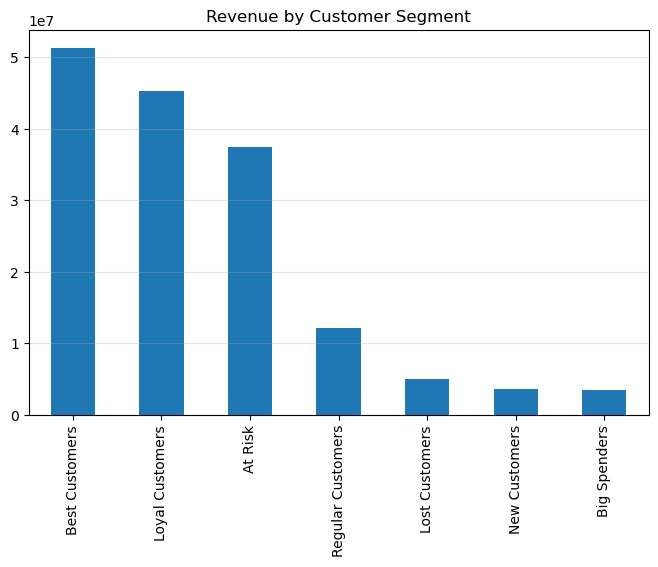

In [214]:
segment_rev = (
    rfm.groupby('segment')['Monetary'].sum().sort_values(ascending=False))

segment_rev.plot.bar(figsize=(8,5))
plt.xlabel('')
plt.title('Revenue by Customer Segment')
plt.grid(axis='y',alpha=0.3)
plt.show()


- Best Customers generated the highest share of total revenue across the entire historical period.
- Loyal Customers also contributed significantly to overall business revenue, indicating stable long-term purchasing behavior.
- A large revenue contribution from the At Risk segment suggests that many previously valuable customers have recently become less active.
- Lost Customers and New Customers contributed only a small portion of total revenue.
- The business historically relied heavily on repeat and loyal customers rather than one-time buyers.


                          -Recent 12-Month RFM Analysis

In [215]:
last_date = data['purchase_date'].max()

recent_data = data[data['purchase_date'] >= last_date - pd.DateOffset(years=1)]

snapshot_date2 = recent_data['purchase_date'].max() + pd.Timedelta(days=1)

In [216]:
rfm_recent = recent_data.groupby('cid', observed = True).agg({
    'purchase_date' : lambda x:(snapshot_date2 - x.max()).days,
    'tid' : 'count',
    'net_amount' : 'sum'}).reset_index()

In [219]:
rfm_recent.columns = ['cid','Recency', 'Frequency', 'Monetary']

In [220]:
rfm_recent['R_score'] = pd.qcut(
    rfm_recent['Recency'],
    5,
    labels = [5,4,3,2,1])
        
rfm_recent['F_score'] = pd.qcut(
    rfm_recent['Frequency'].rank(method='first'),
    5,
    labels = [1,2,3,4,5])
        
rfm_recent['M_score'] = pd.qcut(
    rfm_recent['Monetary'],
    5,
    labels = [1,2,3,4,5])

In [221]:
rfm_recent['RFM_score'] = (
    rfm_recent['R_score'].astype(str) +
    rfm_recent['F_score'].astype(str) +
    rfm_recent['M_score'].astype(str))

In [222]:
rfm_recent['segment'] = rfm_recent.apply(segment_customer, axis=1)

rfm_recent['segment'].value_counts()
rfm_recent
rfm_recent.to_csv('rfm_recent_ecommerce.scv',index=False)

In [ ]:
segment_rev_recent = (
    rfm_recent.groupby('segment')['Monetary'].sum().sort_values(ascending=False))

segment_rev.plot.bar(figsize=(8,5))
plt.xlabel('')
plt.title('Revenue by Customer Segment Recent')
plt.grid(axis='y',alpha=0.3)
plt.show()

- In the recent period, the At Risk segment generated the highest share of revenue, indicating a growing risk of customer churn.
- Revenue contribution from Best Customers decreased compared to the historical RFM analysis.
- Loyal Customers still remain an important revenue driver, but their dominance weakened over time.
- Big Spenders became more visible in the recent analysis, suggesting that some customers generate high revenue despite lower purchase frequency.
- The increase in At Risk customers may indicate weakening customer retention and declining engagement among previously active users.


                                     Business Recommendations

- Focus on retention campaigns for At Risk and Loyal Customers.
- Implement personalized offers and loyalty programs for Best Customers.
- Use re-engagement campaigns for Lost Customers.
- Monitor customer activity trends regularly to identify early signs of churn.
- Develop targeted marketing strategies for high-value customer segments.